# Bayesian Neural Networks for Oscillator Surrogates

**Learning objectives**
- Anchor Bayesian intuition to a damped oscillator and carry that example through every section
- Experience exact Bayesian inference on toy problems before jumping to approximate methods
- Derive the variational inference (VI) objective and understand its Gaussian limitations
- Build a Bayesian neural network (BNN) surrogate that interpolates sensor data and exposes extrapolation uncertainty

**Colab:** [![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=flat-square&logo=googlecolab)](https://colab.research.google.com/github/kks32-courses/sciml/blob/main/docs/09-bayes-cnf/09a-bayes-to-flows.ipynb)



## How to use this notebook
- Install `torchdiffeq` if needed (`pip install torchdiffeq`).
- The notebook automatically picks CUDA or Apple Silicon (MPS) if available; otherwise it runs on CPU.
- Every section is self-contained. Read the markdown carefully—the explanations follow a Gilbert Strang style: concrete example → mathematical idea → computational realization.



In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal, Uniform
from torchdiffeq import odeint

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True


def choose_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')


torch.set_default_dtype(torch.float32)
device = choose_device()
torch.manual_seed(0)
np.random.seed(0)
print(f'Using device: {device}')



Using device: mps


## Segment 1 – The anchor problem: a damped oscillator

Strang would never start with abstraction; neither do we. Consider the damped oscillator

$$\ddot{x} + 2\zeta\omega_n \dot{x} + \omega_n^2 x = 0$$

with unknown damping ratio $\zeta$ and natural frequency $\omega_n$. The forward model integrates this ODE (a second-order linear system) to predict $x(t)$ for a candidate $\theta = (\zeta, \omega_n)$, while the inverse problem adjusts $\theta$ so that the predicted trajectory matches sparse displacement sensors.

For the anchor that motivated this notebook the interesting physics is tightly localized: practical designs sit around lightly damped values $0.075 \le \zeta \le 0.10$ and near-resonant frequencies $1.05 \le \omega_n \le 1.15$. Whenever you examine posterior plots later on, zoom into that rectangle first—the credible region there answers the engineering question "did we recover the expected damping and frequency?" Leakage of mass outside the box signals either modelling error or insufficient data resolution, so the zoomed view doubles as a built-in diagnostic.



In [2]:
def damped_oscillator(t, state, zeta, omega_n):
    # Time derivative for the 2-state oscillator system.
    x = state[..., 0]
    v = state[..., 1]
    dxdt = v
    dvdt = -2.0 * zeta * omega_n * v - omega_n**2 * x
    return torch.stack((dxdt, dvdt), dim=-1)


def solve_oscillator(theta, t_eval, x0=1.0, v0=0.0):
    # Run on CPU to avoid MPS float64 compatibility issues with torchdiffeq
    compute_device = torch.device('cpu')
    theta_cpu = theta.to(compute_device)
    t_eval_cpu = t_eval.to(compute_device)

    zeta, omega_n = theta_cpu
    y0 = torch.tensor([x0, v0], dtype=torch.float32, device=compute_device)
    sol = odeint(lambda t, y: damped_oscillator(t, y, zeta, omega_n), y0, t_eval_cpu)
    return sol[:, 0].to(t_eval.device)

### 1A. Generate synthetic data
We simulate the oscillator with true parameters $\theta_{\text{true}} = (0.08, 1.1)$, sample noisy measurements up to 6 seconds, and reserve the interval $[6, 8]$ for extrapolation tests. This mirrors how SciML models often receive data only in part of the time domain.



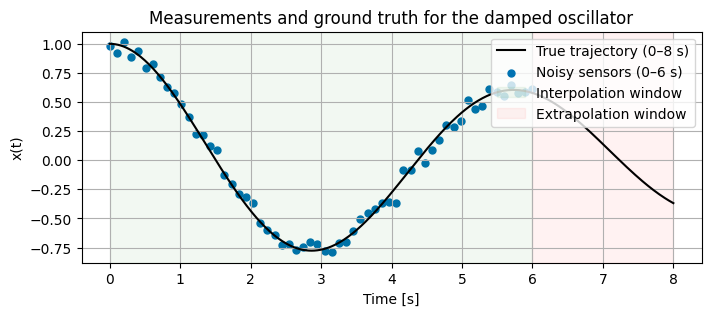

In [3]:
theta_true = torch.tensor([0.08, 1.1], device=device)
t_all = torch.linspace(0.0, 8.0, steps=400, device=device)
x_all = solve_oscillator(theta_true, t_all)

# Training (interpolation) window: 0 to 6 seconds
train_mask = t_all <= 6.0
t_train = torch.linspace(0.0, 6.0, steps=60, device=device)
x_train_clean = solve_oscillator(theta_true, t_train)
noise_std = 0.05
x_train = x_train_clean + noise_std * torch.randn_like(x_train_clean)

with torch.no_grad():
    t_extrap = torch.linspace(6.0, 8.0, steps=80, device=device)
    x_extrap_clean = solve_oscillator(theta_true, t_extrap)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_all.cpu(), x_all.cpu(), label='True trajectory (0–8 s)', color='black')
ax.scatter(t_train.cpu(), x_train.cpu(), s=25, color='C0', label='Noisy sensors (0–6 s)')
ax.axvspan(0, 6, color='green', alpha=0.05, label='Interpolation window')
ax.axvspan(6, 8, color='red', alpha=0.05, label='Extrapolation window')
ax.set_xlabel('Time [s]')
ax.set_ylabel('x(t)')
ax.set_title('Measurements and ground truth for the damped oscillator')
ax.legend(loc='upper right')
plt.show()



### 1B. Exact Bayes in miniature
To motivate approximations, we compute the posterior on a $60\times60$ grid. This is feasible only because the parameter space is 2D; neural surrogates would have thousands of weights.



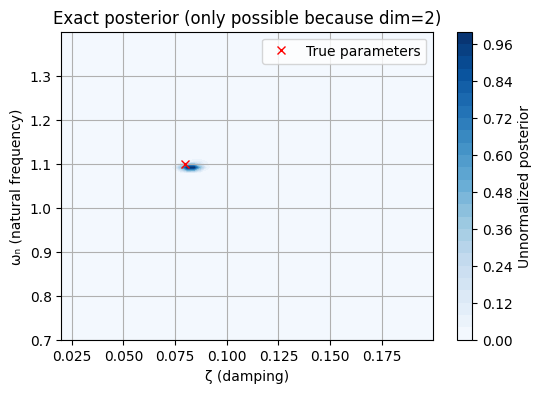

In [4]:
prior_zeta = Uniform(0.0, 0.25)
prior_omega = Uniform(0.6, 1.6)


def log_prior_oscillator(theta):
    zeta = theta[..., 0]
    omega = theta[..., 1]
    return prior_zeta.log_prob(zeta) + prior_omega.log_prob(omega)


def log_likelihood_oscillator(theta, y_obs, noise_std, t_eval):
    if theta.ndim == 1:
        theta = theta.unsqueeze(0)
    log_lik = []
    for th in theta:
        pred = solve_oscillator(th, t_eval)
        log_lik.append(Normal(pred, noise_std).log_prob(y_obs).sum())
    return torch.stack(log_lik)

zeta_vals = torch.linspace(0.02, 0.2, steps=60, device=device)
omega_vals = torch.linspace(0.7, 1.4, steps=60, device=device)
posterior_grid = torch.zeros(len(zeta_vals), len(omega_vals))

for i, zeta in enumerate(zeta_vals):
    for j, omega in enumerate(omega_vals):
        theta = torch.tensor([zeta, omega], device=device)
        log_post = log_prior_oscillator(theta) + log_likelihood_oscillator(theta, x_train, noise_std, t_train)
        posterior_grid[i, j] = log_post

posterior_grid = torch.exp(posterior_grid - posterior_grid.max())
ZETA, OMEGA = torch.meshgrid(zeta_vals.cpu(), omega_vals.cpu(), indexing='ij')

fig, ax = plt.subplots(figsize=(6, 4))
cs = ax.contourf(ZETA, OMEGA, posterior_grid.cpu().numpy(), levels=25, cmap='Blues')
ax.plot(theta_true[0].cpu(), theta_true[1].cpu(), 'rx', label='True parameters')
ax.set_xlabel('ζ (damping)')
ax.set_ylabel('ωₙ (natural frequency)')
ax.set_title('Exact posterior (only possible because dim=2)')
ax.legend()
fig.colorbar(cs, ax=ax, label='Unnormalized posterior')
plt.show()



## Segment 2 – 1D warm-up: $y = \theta^2 + \epsilon$

Before we attack neural-network weights, we warm up with the simplest nonlinear inverse map Strang-style: define a scalar parameter $\theta$, push it through the forward map $f(\theta) = \theta^2$, and observe $y = f(\theta) + \epsilon$ with $\epsilon \sim \mathcal{N}(0, \sigma^2)$. This toy problem pins down every ingredient by hand:

1. Choose an easily visualized prior, e.g., $p(\theta) = \mathcal{N}(0, 1)$.
2. The likelihood becomes $\log p(y\mid \theta) = -\tfrac{1}{2\sigma^2}(y - \theta^2)^2 + \text{const}$; you can see exactly how residuals enter the loss.
3. Because squaring is two-to-one, any positive $y$ induces a bimodal posterior with modes near $\pm\sqrt{y}$. That symmetry is the perfect stress test for approximate inference.

Working through this warm-up forces us to reason about priors, likelihoods, and posterior geometry before the BNN appears. Once those ideas are concrete in one dimension, every later tensor operation is just bookkeeping of the same story.



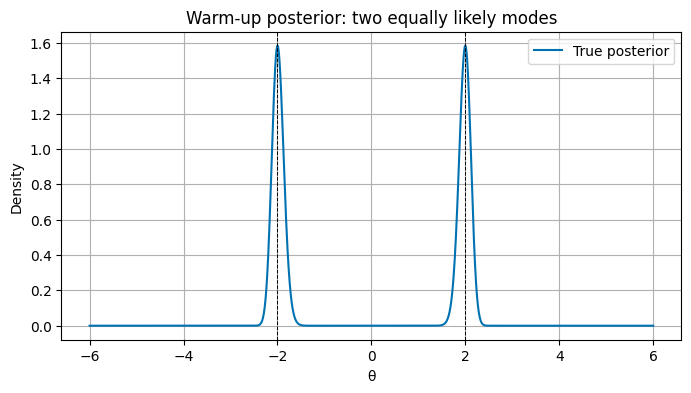

In [5]:
scalar_prior = Normal(0.0, 5.0)
scalar_noise = 0.5
y_obs_scalar = torch.tensor(4.0)


def log_prior_scalar(theta):
    return scalar_prior.log_prob(theta)


def log_likelihood_scalar(theta, y_obs, noise_std=scalar_noise):
    y_pred = theta ** 2
    return Normal(y_pred, noise_std).log_prob(y_obs)


def log_posterior_scalar(theta, y_obs):
    return log_likelihood_scalar(theta, y_obs) + log_prior_scalar(theta)


theta_grid = torch.linspace(-6.0, 6.0, steps=2000)
log_post_vals = log_posterior_scalar(theta_grid, y_obs_scalar)
posterior_density = torch.exp(log_post_vals - log_post_vals.max())
posterior_density /= posterior_density.sum() * (theta_grid[1] - theta_grid[0])

fig, ax = plt.subplots()
ax.plot(theta_grid, posterior_density, label='True posterior')
ax.axvline(2.0, color='k', linestyle='--', linewidth=0.7)
ax.axvline(-2.0, color='k', linestyle='--', linewidth=0.7)
ax.set_xlabel('θ')
ax.set_ylabel('Density')
ax.set_title('Warm-up posterior: two equally likely modes')
ax.legend()
plt.show()



## Segment 3 – Variational inference as optimization

The exact posterior is rarely available. VI posits a tractable trial family $q_\phi(\theta)$ (we start with a Gaussian) and maximizes the evidence lower bound (ELBO)

$$\mathcal{L}(\phi) = \mathbb{E}_{q_\phi}[\log p(y\mid\theta)] - \mathrm{KL}(q_\phi(\theta) \| p(\theta)).$$

It helps to give names to the two pieces:

- **Reconstruction term** $= \mathbb{E}_{q} [\log p(y\mid\theta)]$. For Gaussian observation noise this is the familiar data-fit term $-\tfrac{1}{2\sigma^2}\|y - f(\theta)\|^2$ plus constants, so higher values mean we explain the measurements well.
- **Regularization term** $= -\mathrm{KL}(q\|p) = \mathbb{E}_{q}[\log p(\theta) - \log q(\theta)]$. This pushes the approximate posterior to stay close to the prior and penalizes overly confident weights.

Most optimizers minimize a loss, so in code we optimize $-\mathcal{L} = -$(Reconstruction $+$ Regularization). Viewing the ELBO this way makes the BNN training loop feel like autoencoder training: one piece rewards accurate reconstruction, the other keeps the weights well-behaved. The reparameterization trick ($\theta = \mu + \sigma\epsilon$ with $\epsilon \sim \mathcal{N}(0,1)$) delivers low-variance Monte Carlo estimates of both components, letting Adam push $q_\phi$ uphill on the ELBO with standard gradients.



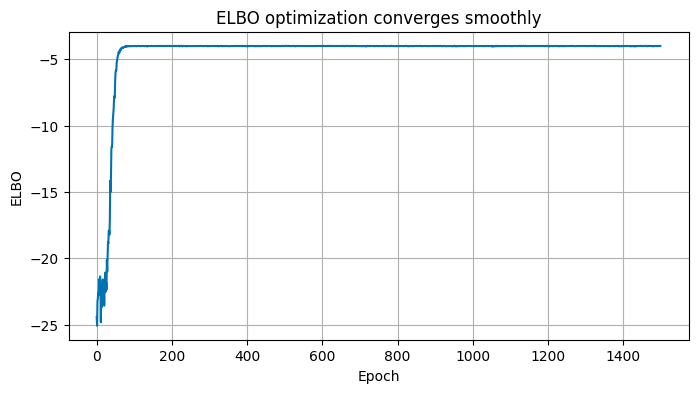

In [6]:
class VariationalGaussian(nn.Module):
    def __init__(self, init_mu=0.0, init_log_std=0.0):
        super().__init__()
        self.mu = nn.Parameter(torch.tensor(init_mu, dtype=torch.float32))
        self.log_std = nn.Parameter(torch.tensor(init_log_std, dtype=torch.float32))

    def rsample(self, n_samples):
        eps = torch.randn(n_samples)
        return self.mu + torch.exp(self.log_std) * eps

    def log_prob(self, theta):
        std = torch.exp(self.log_std)
        return Normal(self.mu, std).log_prob(theta)


gaussian_vi = VariationalGaussian()
optimizer = optim.Adam(gaussian_vi.parameters(), lr=0.05)
elbo_history = []
n_epochs = 1500
n_mc = 256

for epoch in range(1, n_epochs + 1):
    optimizer.zero_grad()
    theta_samples = gaussian_vi.rsample(n_mc)
    log_q = gaussian_vi.log_prob(theta_samples)
    log_prior_vals = log_prior_scalar(theta_samples)
    log_like_vals = log_likelihood_scalar(theta_samples, y_obs_scalar)
    elbo = (log_like_vals + log_prior_vals - log_q).mean()
    (-elbo).backward()
    optimizer.step()
    elbo_history.append(elbo.item())

fig, ax = plt.subplots()
ax.plot(elbo_history)
ax.set_xlabel('Epoch')
ax.set_ylabel('ELBO')
ax.set_title('ELBO optimization converges smoothly')
plt.show()



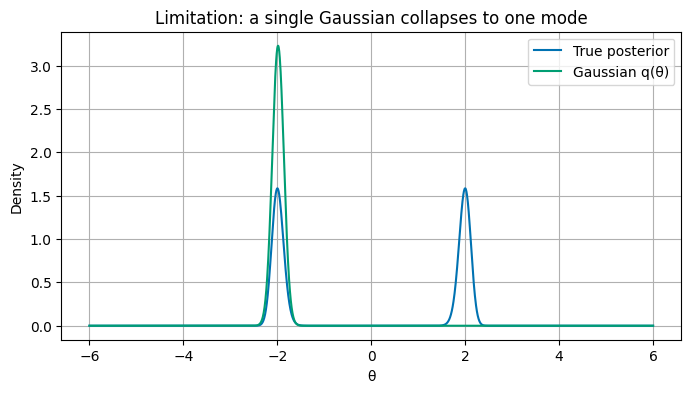

In [7]:
with torch.no_grad():
    q_density = torch.exp(gaussian_vi.log_prob(theta_grid))
    q_density /= q_density.sum() * (theta_grid[1] - theta_grid[0])

fig, ax = plt.subplots()
ax.plot(theta_grid, posterior_density, label='True posterior')
ax.plot(theta_grid, q_density, label='Gaussian q(θ)')
ax.set_xlabel('θ')
ax.set_ylabel('Density')
ax.set_title('Limitation: a single Gaussian collapses to one mode')
ax.legend()
plt.show()



The take-away: VI is powerful, but its success depends entirely on $q_\phi$. Neural networks introduce thousands of parameters, so we need expressive surrogates with good uncertainty estimates. Enter Bayesian neural networks.



## Segment 4 – Bayesian neural network surrogate for the oscillator

Instead of inferring just $\zeta$ and $\omega_n$, we now infer a full function $x(t)$ via a BNN. The network sees noisy sensors on $[0, 6]$ seconds and must interpolate as well as extrapolate to $[6, 8]$ seconds. Think of it as a reduced-order model that carries uncertainty with it.



### 4A. Prepare normalized inputs
BNNs benefit from well-scaled inputs. We map time to $[-1, 1]$ using the training interval. Evaluation points (including extrapolation) use the same normalization.



In [8]:
# Normalize time to [-1, 1] based on the interpolation window
min_t, max_t = t_train.min(), t_train.max()

def normalize_time(t):
    return 2 * (t - min_t) / (max_t - min_t) - 1


t_train_norm = normalize_time(t_train).unsqueeze(-1)
x_train_targets = x_train.unsqueeze(-1)

# Dense evaluation grid (0–8 seconds)
t_eval = torch.linspace(0.0, 8.0, steps=300, device=device).unsqueeze(-1)
t_eval_norm = normalize_time(t_eval)
true_eval = solve_oscillator(theta_true, t_eval.squeeze(-1)).unsqueeze(-1)



### 4B. Bayes-by-Backprop layers
Each linear layer stores $(\mu, \rho)$ parameters with $\sigma = \log(1 + e^\rho)$. Sampling weights yields $\log q$ and $\log p$ terms for the ELBO just like the scalar case, but now across hundreds of weights.



In [9]:
class BayesianLinear(nn.Module):
    def __init__(self, in_features, out_features, prior_std=1.0):
        super().__init__()
        self.weight_mu = nn.Parameter(torch.randn(out_features, in_features) * 0.1)
        self.weight_rho = nn.Parameter(torch.full((out_features, in_features), -3.0))
        self.bias_mu = nn.Parameter(torch.zeros(out_features))
        self.bias_rho = nn.Parameter(torch.full((out_features,), -3.0))
        self.prior = Normal(0.0, prior_std)

    def _sample(self):
        weight_sigma = torch.log1p(torch.exp(self.weight_rho))
        bias_sigma = torch.log1p(torch.exp(self.bias_rho))
        weight = self.weight_mu + weight_sigma * torch.randn_like(weight_sigma)
        bias = self.bias_mu + bias_sigma * torch.randn_like(bias_sigma)
        log_q = Normal(self.weight_mu, weight_sigma).log_prob(weight).sum()
        log_q += Normal(self.bias_mu, bias_sigma).log_prob(bias).sum()
        log_p = self.prior.log_prob(weight).sum() + self.prior.log_prob(bias).sum()
        return weight, bias, log_q, log_p

    def forward(self, x, sample=True):
        if self.training or sample:
            weight, bias, log_q, log_p = self._sample()
        else:
            weight, bias = self.weight_mu, self.bias_mu
            log_q = log_p = torch.tensor(0.0, device=x.device)
        return F.linear(x, weight, bias), log_q, log_p


class BayesianMLP(nn.Module):
    def __init__(self, hidden_dim=64, prior_std=1.0):
        super().__init__()
        self.layer1 = BayesianLinear(1, hidden_dim, prior_std)
        self.layer2 = BayesianLinear(hidden_dim, hidden_dim, prior_std)
        self.layer3 = BayesianLinear(hidden_dim, 1, prior_std)

    def forward(self, x, sample=True):
        log_q = 0.0
        log_p = 0.0
        out, lq, lp = self.layer1(x, sample)
        log_q += lq
        log_p += lp
        out = torch.tanh(out)
        out, lq, lp = self.layer2(out, sample)
        log_q += lq
        log_p += lp
        out = torch.tanh(out)
        out, lq, lp = self.layer3(out, sample)
        log_q += lq
        log_p += lp
        return out, log_q, log_p

    def predictive_samples(self, x, n_samples=200):
        self.eval()
        preds = []
        with torch.no_grad():
            for _ in range(n_samples):
                y_hat, _, _ = self.forward(x, sample=True)
                preds.append(y_hat)
        return torch.stack(preds)


def bayes_by_backprop_step(model, x, y, noise_std, n_samples=4):
    log_q = 0.0
    log_p = 0.0
    log_likelihood = 0.0
    for _ in range(n_samples):
        preds, sample_log_q, sample_log_p = model(x)
        log_q += sample_log_q
        log_p += sample_log_p
        log_likelihood += Normal(preds, noise_std).log_prob(y).sum()
    log_q /= n_samples
    log_p /= n_samples
    log_likelihood /= n_samples
    return log_q - log_p - log_likelihood



### 4C. Train the surrogate
We keep the optimizer simple (Adam) and run long enough for the network to capture the oscillations. The ELBO automatically balances data fit and weight uncertainty.



Epoch 500, negative ELBO: 5022.455
Epoch 1000, negative ELBO: 2289.078
Epoch 1500, negative ELBO: 1568.338
Epoch 2000, negative ELBO: 970.782
Epoch 2500, negative ELBO: 906.166
Epoch 3000, negative ELBO: 826.065
Epoch 3500, negative ELBO: 753.771
Epoch 4000, negative ELBO: 725.894


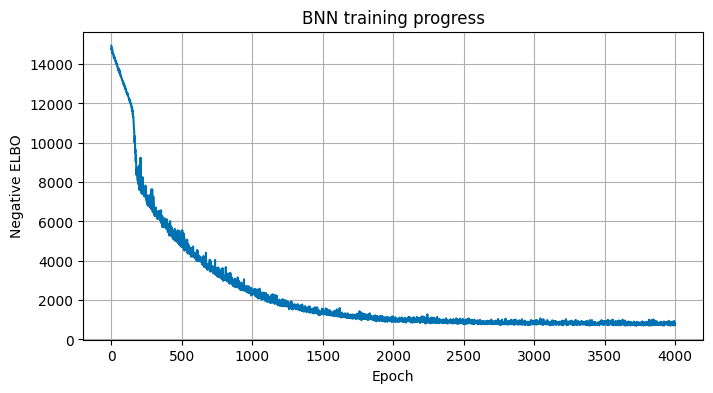

In [10]:
model_bnn = BayesianMLP(hidden_dim=64, prior_std=1.0).to(device)
optimizer = optim.Adam(model_bnn.parameters(), lr=5e-3)
loss_history = []
n_epochs = 4000

for epoch in range(1, n_epochs + 1):
    optimizer.zero_grad()
    loss = bayes_by_backprop_step(model_bnn, t_train_norm, x_train_targets, noise_std, n_samples=6)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if epoch % 500 == 0:
        print(f'Epoch {epoch}, negative ELBO: {loss.item():.3f}')

fig, ax = plt.subplots()
ax.plot(loss_history)
ax.set_xlabel('Epoch')
ax.set_ylabel('Negative ELBO')
ax.set_title('BNN training progress')
plt.show()



### 4D. Predict and visualize uncertainty
We draw 300 posterior samples for each evaluation time. The network interpolates well inside $[0,6]$ and becomes more uncertain once we ask for $t>6$.



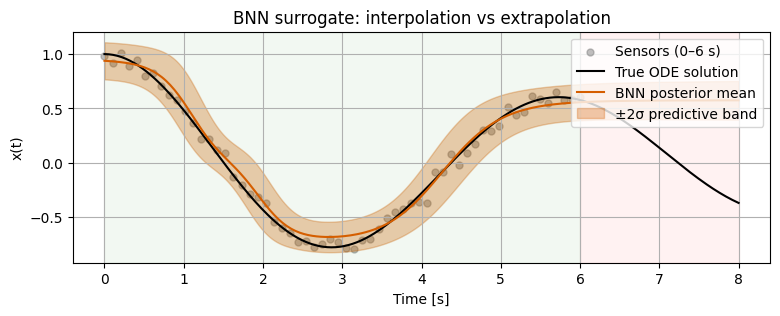

In [11]:
with torch.no_grad():
    preds = model_bnn.predictive_samples(t_eval_norm, n_samples=300)
mean_pred = preds.mean(dim=0)
std_pred = preds.std(dim=0)

fig, ax = plt.subplots(figsize=(9, 3))
ax.scatter(t_train.cpu(), x_train.cpu(), s=25, color='gray', alpha=0.5, label='Sensors (0–6 s)')
ax.plot(t_eval.squeeze().cpu(), true_eval.squeeze().cpu(), color='black', linewidth=1.5, label='True ODE solution')
ax.plot(t_eval.squeeze().cpu(), mean_pred.squeeze().cpu(), color='C2', label='BNN posterior mean')
ax.fill_between(
    t_eval.squeeze().cpu(),
    (mean_pred - 2 * std_pred).squeeze().cpu(),
    (mean_pred + 2 * std_pred).squeeze().cpu(),
    color='C2', alpha=0.3, label='±2σ predictive band'
)
ax.axvspan(0, 6, color='green', alpha=0.05)
ax.axvspan(6, 8, color='red', alpha=0.05)
ax.set_xlabel('Time [s]')
ax.set_ylabel('x(t)')
ax.set_title('BNN surrogate: interpolation vs extrapolation')
ax.legend(loc='upper right')
plt.show()



To emphasize extrapolation, we overlay sample trajectories. Inside the data-rich region the samples cluster tightly; beyond six seconds they fan out, signalling that the surrogate is guessing.



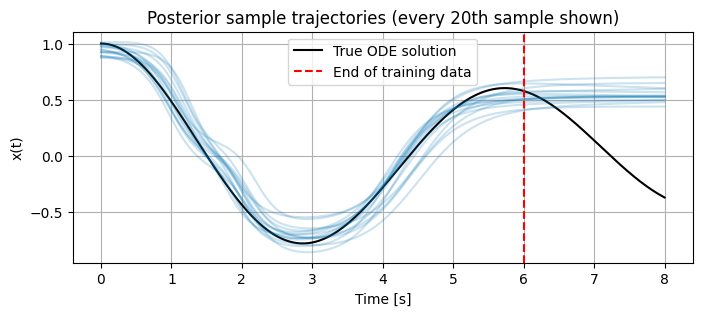

In [12]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_eval.squeeze().cpu(), true_eval.squeeze().cpu(), color='black', linewidth=1.5, label='True ODE solution')
for sample in preds[::20]:
    ax.plot(t_eval.squeeze().cpu(), sample.squeeze().cpu(), color='C0', alpha=0.2)
ax.axvline(6.0, color='red', linestyle='--', label='End of training data')
ax.set_xlabel('Time [s]')
ax.set_ylabel('x(t)')
ax.set_title('Posterior sample trajectories (every 20th sample shown)')
ax.legend()
plt.show()



## Key takeaways and exercises

1. Exact Bayesian inference is motivating but infeasible for high-dimensional surrogates.
2. Variational inference reframes inference as optimization; its quality hinges on $q_\phi$.
3. Bayesian neural networks provide function-valued posteriors—ideal for SciML surrogates that must interpolate and extrapolate.

**Exercises**
- Increase the observation noise and watch the posterior predictive band widen.
- Change the BNN prior (e.g., smaller `prior_std`) and observe how bias vs variance trade-offs shift.
- Replace the tanh activations with sinusoidal ones (SIREN) to see whether oscillatory priors help extrapolation.
- Train on $[0,4]$ seconds only and quantify how quickly uncertainty grows.

